In [1]:
# === KOMÓRKA 1: Importy i wczytanie danych ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('creditcard.csv')
print(f"Rozmiar zbioru: {df.shape}")
print(f"\nRozkład klas:")
print(df['Class'].value_counts())
print(f"\nProcent fraudów: {df['Class'].mean()*100:.4f}%")

Rozmiar zbioru: (284807, 31)

Rozkład klas:
Class
0    284315
1       492
Name: count, dtype: int64

Procent fraudów: 0.1727%


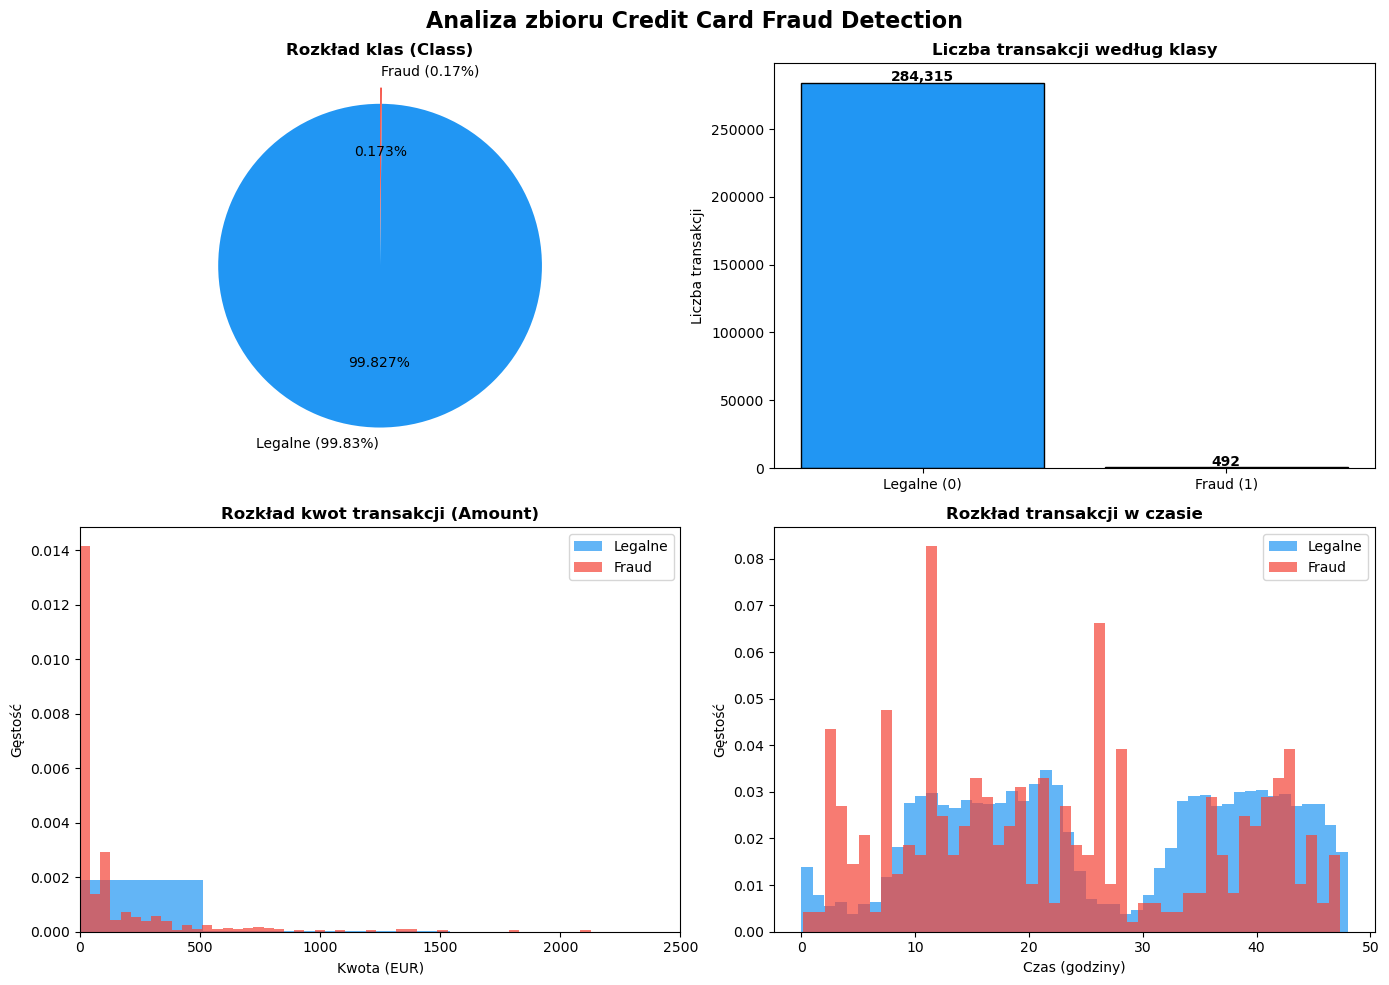

Wykres zapisany jako wizualizacje_raport1.png


In [2]:
# === KOMÓRKA 2: Wizualizacje do Raportu 1 ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analiza zbioru Credit Card Fraud Detection', fontsize=16, fontweight='bold')

# 1. Rozkład klas (pie chart)
class_counts = df['Class'].value_counts()
axes[0,0].pie(class_counts, labels=['Legalne (99.83%)', 'Fraud (0.17%)'],
              colors=['#2196F3', '#F44336'], autopct='%1.3f%%',
              startangle=90, explode=(0, 0.1))
axes[0,0].set_title('Rozkład klas (Class)', fontweight='bold')

# 2. Rozkład klas (bar chart)
axes[0,1].bar(['Legalne (0)', 'Fraud (1)'], class_counts.values,
              color=['#2196F3', '#F44336'], edgecolor='black')
axes[0,1].set_title('Liczba transakcji według klasy', fontweight='bold')
axes[0,1].set_ylabel('Liczba transakcji')
for i, v in enumerate(class_counts.values):
    axes[0,1].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# 3. Rozkład kwot transakcji (Amount)
axes[1,0].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7,
               color='#2196F3', label='Legalne', density=True)
axes[1,0].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7,
               color='#F44336', label='Fraud', density=True)
axes[1,0].set_title('Rozkład kwot transakcji (Amount)', fontweight='bold')
axes[1,0].set_xlabel('Kwota (EUR)')
axes[1,0].set_ylabel('Gęstość')
axes[1,0].legend()
axes[1,0].set_xlim(0, 2500)

# 4. Rozkład w czasie (Time)
axes[1,1].hist(df[df['Class']==0]['Time']/3600, bins=48, alpha=0.7,
               color='#2196F3', label='Legalne', density=True)
axes[1,1].hist(df[df['Class']==1]['Time']/3600, bins=48, alpha=0.7,
               color='#F44336', label='Fraud', density=True)
axes[1,1].set_title('Rozkład transakcji w czasie', fontweight='bold')
axes[1,1].set_xlabel('Czas (godziny)')
axes[1,1].set_ylabel('Gęstość')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('wizualizacje_raport1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Wykres zapisany jako wizualizacje_raport1.png")

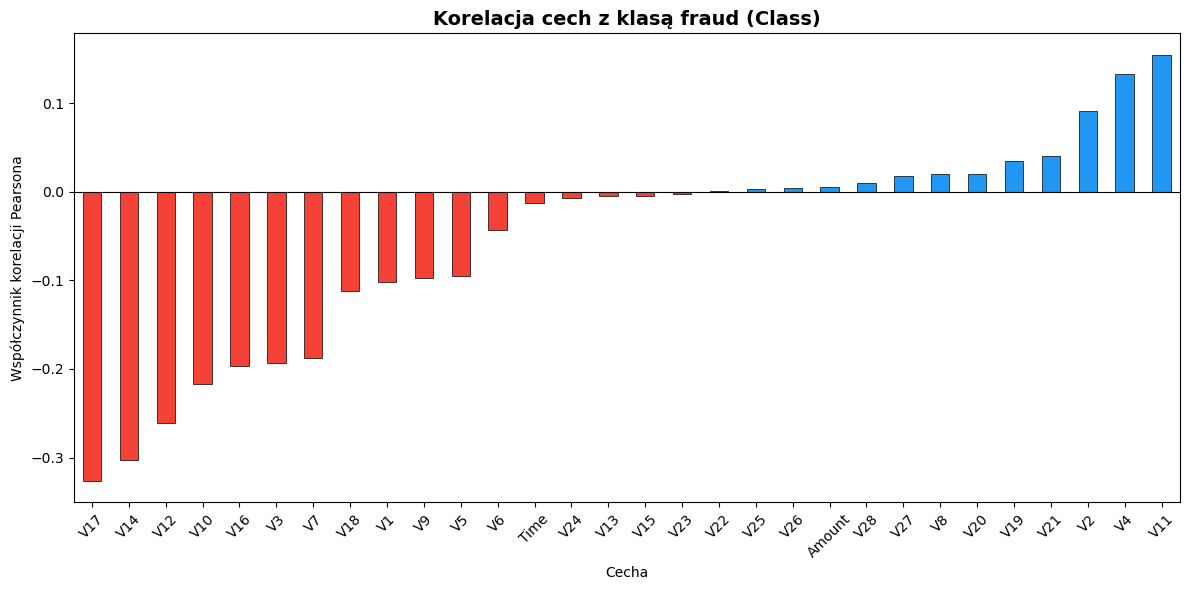

Wykres zapisany jako korelacje_raport1.png


In [3]:
# === KOMÓRKA 3: Korelacja cech z klasą fraud ===
fig, ax = plt.subplots(figsize=(12, 6))

correlations = df.corr()['Class'].drop('Class').sort_values()

colors = ['#F44336' if x < 0 else '#2196F3' for x in correlations]
correlations.plot(kind='bar', color=colors, ax=ax, edgecolor='black', linewidth=0.5)

ax.set_title('Korelacja cech z klasą fraud (Class)', fontweight='bold', fontsize=14)
ax.set_xlabel('Cecha')
ax.set_ylabel('Współczynnik korelacji Pearsona')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('korelacje_raport1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Wykres zapisany jako korelacje_raport1.png")